In [1]:
# Cell 1: Reproducibility + imports
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import os
import json
import pickle
import time
import ast
from collections import Counter

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [2]:
# Cell 2: Install required packages
!pip install torch_geometric -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.3 MB/s eta 0:00:00


In [3]:
# Cell 3: Locate attached checkpoint files from Task 1 and Task 2 notebooks
for root, dirs, files in os.walk("/kaggle/input"):
    for f in files:
        if f.endswith(".pt") or f.endswith(".json"):
            print(os.path.join(root, f))

/kaggle/input/notebooks/sumaiyasultana1223/cse715/__huggingface_repos__.json
/kaggle/input/notebooks/sumaiyasultana1223/cse715/__output__.json
/kaggle/input/notebooks/sumaiyasultana1223/cse715/checkpoints/task1_bert_tagger.pt
/kaggle/input/notebooks/sumaiyasultana1223/cse715/results/task1_config.json
/kaggle/input/notebooks/sumaiyasultana1223/cse715/results/task1_history.json
/kaggle/input/notebooks/sumaiyasultana1223/task2-gnn-music-graph/__output__.json
/kaggle/input/notebooks/sumaiyasultana1223/task2-gnn-music-graph/checkpoints/task2_cnn_baseline.pt
/kaggle/input/notebooks/sumaiyasultana1223/task2-gnn-music-graph/checkpoints/task2_gnn_classifier.pt
/kaggle/input/notebooks/sumaiyasultana1223/task2-gnn-music-graph/results/task2_config.json
/kaggle/input/notebooks/sumaiyasultana1223/task2-gnn-music-graph/results/task2_history.json
/kaggle/input/notebooks/sumaiyasultana1223/task2-gnn-music-graph/results/task2_cnn_history.json
/kaggle/input/notebooks/sumaiyasultana1223/task2-gnn-music-gr

In [4]:
# Cell 4: Define paths and load configs
TASK1_DIR = "/kaggle/input/notebooks/sumaiyasultana1223/cse715"
TASK2_DIR = "/kaggle/input/notebooks/sumaiyasultana1223/task2-gnn-music-graph"

with open(os.path.join(TASK1_DIR, "results", "task1_config.json")) as f:
    task1_config = json.load(f)

with open(os.path.join(TASK2_DIR, "results", "task2_config.json")) as f:
    task2_config = json.load(f)

print("Task 1 config:")
print(json.dumps(task1_config, indent=2)[:500])
print("\nTask 2 config:")
print(json.dumps(task2_config, indent=2))

Task 1 config:
{
  "model_name": "distilbert-base-uncased",
  "top_genre_ids": [
    38,
    15,
    12,
    1235,
    10,
    17,
    25,
    1,
    21,
    32,
    107,
    76,
    41,
    27,
    18,
    42,
    66,
    2,
    250,
    103,
    4,
    5,
    85,
    236,
    30,
    247,
    183,
    47,
    58,
    45
  ],
  "top_genre_names": [
    "Experimental",
    "Electronic",
    "Rock",
    "Instrumental",
    "Pop",
    "Folk",
    "Punk",
    "Avant-Garde",
    "Hip-Hop",
    "Noise",
    "Ambien

Task 2 config:
{
  "genre_to_idx": {
    "Electronic": 0,
    "Experimental": 1,
    "Folk": 2,
    "Hip-Hop": 3,
    "Instrumental": 4,
    "International": 5,
    "Pop": 6,
    "Rock": 7
  },
  "in_channels": 12,
  "hidden_channels": 64,
  "num_layers": 2,
  "similarity_percentile": 70,
  "segment_duration": 5.0,
  "test_acc": 0.28165007112375534,
  "test_macro_f1": 0.27610068032368396
}


In [5]:
# Cell 5: Rebuild the BERT model architecture and load Task 1 weights
from transformers import DistilBertModel, DistilBertTokenizerFast

MODEL_NAME = task1_config["model_name"]  # should be "distilbert-base-uncased"
TASK1_MAX_LEN = task1_config["max_len"]
task1_top_genre_ids = task1_config["top_genre_ids"]
task1_top_genre_names = task1_config["top_genre_names"]

class BertTagClassifier(nn.Module):
    def __init__(self, model_name, num_labels, dropout=0.3):
        super().__init__()
        self.bert = DistilBertModel.from_pretrained(model_name)
        hidden_size = self.bert.config.hidden_size
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_size, num_labels)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_token = outputs.last_hidden_state[:, 0, :]
        x = self.dropout(cls_token)
        logits = self.classifier(x)
        return logits

bert_tagger = BertTagClassifier(MODEL_NAME, num_labels=len(task1_top_genre_ids)).to(device)
bert_tagger.load_state_dict(torch.load(os.path.join(TASK1_DIR, "checkpoints", "task1_bert_tagger.pt"), map_location=device))
print("Task 1 BERT loaded successfully.")

tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Task 1 BERT loaded successfully.


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [6]:
# Cell 6: Rebuild the GNN model architecture and load Task 2 weights
from torch_geometric.nn import SAGEConv, global_mean_pool

task2_genre_to_idx = task2_config["genre_to_idx"]
GNN_IN_CHANNELS = task2_config["in_channels"]
GNN_HIDDEN = task2_config["hidden_channels"]
GNN_LAYERS = task2_config["num_layers"]

class GraphSAGEClassifier(nn.Module):
    def __init__(self, in_channels=12, hidden_channels=64, num_classes=8, num_layers=2, dropout=0.3):
        super().__init__()
        self.convs = nn.ModuleList()
        self.convs.append(SAGEConv(in_channels, hidden_channels))
        for _ in range(num_layers - 1):
            self.convs.append(SAGEConv(hidden_channels, hidden_channels))
        self.dropout = dropout
        self.classifier = nn.Linear(hidden_channels, num_classes)

    def forward(self, x, edge_index, batch):
        for conv in self.convs:
            x = conv(x, edge_index)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        g = global_mean_pool(x, batch)
        logits = self.classifier(g)
        return logits

gnn_classifier = GraphSAGEClassifier(
    in_channels=GNN_IN_CHANNELS, hidden_channels=GNN_HIDDEN, num_classes=len(task2_genre_to_idx), num_layers=GNN_LAYERS
).to(device)
gnn_classifier.load_state_dict(torch.load(os.path.join(TASK2_DIR, "checkpoints", "task2_gnn_classifier.pt"), map_location=device))
print("Task 2 GNN loaded successfully.")

Task 2 GNN loaded successfully.


In [7]:
# Cell 7: Search for cached pickle files in Task 2's outputs
for root, dirs, files in os.walk(TASK2_DIR):
    for f in files:
        if f.endswith(".pkl"):
            print(os.path.join(root, f))

/kaggle/input/notebooks/sumaiyasultana1223/task2-gnn-music-graph/mel_data/mel_spectrograms.pkl
/kaggle/input/notebooks/sumaiyasultana1223/task2-gnn-music-graph/graph_data/segment_features.pkl


In [8]:
# Cell 8: Load cached chroma segment features
GRAPH_DATA_PATH = os.path.join(TASK2_DIR, "graph_data", "segment_features.pkl")

with open(GRAPH_DATA_PATH, "rb") as f:
    saved_data = pickle.load(f)

all_features = saved_data["features"]
failed_tracks = saved_data["failed"]

print(f"Loaded segment features for {len(all_features)} tracks")
print(f"Failed tracks: {len(failed_tracks)}")

Loaded segment features for 7994 tracks
Failed tracks: 6


In [9]:

# Cell 9: Load FMA metadata (needed for both text and genre labels) - corrected path
DATA_ROOT = "/kaggle/input/datasets/imsparsh/fma-free-music-archive-small-medium"

tracks_path = os.path.join(DATA_ROOT, "fma_metadata", "tracks.csv")
tracks = pd.read_csv(tracks_path, index_col=0, header=[0, 1])
track_df = tracks["track"].copy()

def parse_genre_list(x):
    try:
        return ast.literal_eval(x)
    except Exception:
        return []

track_df["genres_all_parsed"] = track_df["genres_all"].apply(parse_genre_list)

genres_df = pd.read_csv(os.path.join(DATA_ROOT, "fma_metadata", "genres.csv"), index_col=0)
id_to_name = genres_df["title"].to_dict()

# Build text field (same as Task 1)
artist_names = tracks[("artist", "name")]
album_titles = tracks[("album", "title")]
track_titles = tracks[("track", "title")]

def build_text(idx):
    a = str(artist_names.get(idx, "") or "")
    al = str(album_titles.get(idx, "") or "")
    t = str(track_titles.get(idx, "") or "")
    return f"{a} - {al} - {t}".strip()

track_df["text"] = [build_text(idx) for idx in track_df.index]
print("Metadata rebuilt. Sample text:", track_df["text"].iloc[0])

Metadata rebuilt. Sample text: AWOL - AWOL - A Way Of Life - Food


In [10]:
# Cell 10: Build multi-label genre vectors, SCOPED to our 7,994 fma_small tracks only
our_track_ids = list(all_features.keys())
subset_track_df = track_df.loc[our_track_ids]

# Find top-K genres WITHIN this subset (may differ slightly from Task 1's full-dataset top-30)
genre_counter = Counter()
for g_list in subset_track_df["genres_all_parsed"]:
    genre_counter.update(g_list)

TOP_K_FUSION = 20
fusion_top_genre_ids = [g for g, _ in genre_counter.most_common(TOP_K_FUSION)]
fusion_top_genre_names = [id_to_name.get(g, str(g)) for g in fusion_top_genre_ids]
print("Fusion task genres:", list(zip(fusion_top_genre_ids, fusion_top_genre_names)))

def multi_hot(genre_list, top_ids):
    vec = np.zeros(len(top_ids), dtype=np.float32)
    id_to_pos = {g: i for i, g in enumerate(top_ids)}
    for g in genre_list:
        if g in id_to_pos:
            vec[id_to_pos[g]] = 1.0
    return vec

subset_track_df = subset_track_df.copy()
subset_track_df["label_vec"] = subset_track_df["genres_all_parsed"].apply(lambda gl: multi_hot(gl, fusion_top_genre_ids))

has_label = subset_track_df["label_vec"].apply(lambda v: v.sum() > 0)
print(f"Tracks with at least one top-{TOP_K_FUSION} genre: {has_label.sum()} out of {len(subset_track_df)}")

Fusion task genres: [(10, 'Pop'), (17, 'Folk'), (2, 'International'), (1235, 'Instrumental'), (38, 'Experimental'), (12, 'Rock'), (15, 'Electronic'), (21, 'Hip-Hop'), (18, 'Soundtrack'), (76, 'Experimental Pop'), (103, 'Singer-Songwriter'), (25, 'Punk'), (182, 'House'), (107, 'Ambient'), (79, 'Reggae - Dub'), (539, 'Rap'), (66, 'Indie-Rock'), (468, 'Dubstep'), (85, 'Garage'), (1, 'Avant-Garde')]
Tracks with at least one top-20 genre: 7994 out of 7994


In [11]:
# Cell 11: Build graph construction function (same as Task 2)
from torch_geometric.data import Data

def build_graph(segment_features, similarity_percentile=70):
    n_nodes = segment_features.shape[0]
    x = torch.tensor(segment_features, dtype=torch.float32)

    edge_list = []
    for i in range(n_nodes - 1):
        edge_list.append([i, i + 1])
        edge_list.append([i + 1, i])

    norm_feats = segment_features / (np.linalg.norm(segment_features, axis=1, keepdims=True) + 1e-8)
    sim_matrix = norm_feats @ norm_feats.T

    non_adj_pairs = []
    non_adj_sims = []
    for i in range(n_nodes):
        for j in range(i + 2, n_nodes):
            non_adj_pairs.append((i, j))
            non_adj_sims.append(sim_matrix[i, j])

    if len(non_adj_sims) > 0:
        threshold = np.percentile(non_adj_sims, similarity_percentile)
        for (i, j), sim in zip(non_adj_pairs, non_adj_sims):
            if sim >= threshold:
                edge_list.append([i, j])
                edge_list.append([j, i])

    edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()
    return Data(x=x, edge_index=edge_index)

In [12]:
# Cell 12: Build fused samples - each sample has a graph, tokenized text, and multi-label vector
MAX_LEN_FUSION = 32

fusion_samples = []

for track_id in our_track_ids:
    feats = all_features[track_id]
    if feats.shape[0] < 2:
        continue

    graph = build_graph(feats, similarity_percentile=70)
    text = subset_track_df.loc[track_id, "text"]
    label_vec = subset_track_df.loc[track_id, "label_vec"]

    fusion_samples.append({
        "track_id": track_id,
        "graph": graph,
        "text": text,
        "label_vec": label_vec
    })

print(f"Built {len(fusion_samples)} fusion samples")
print(fusion_samples[0])

Built 7994 fusion samples
{'track_id': 2, 'graph': Data(x=[6, 12], edge_index=[2, 16]), 'text': 'AWOL - AWOL - A Way Of Life - Food', 'label_vec': array([0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0.], dtype=float32)}


In [13]:
# Cell 13: Artist-grouped train/val/test split (consistent methodology across all 3 tasks)
from sklearn.model_selection import GroupShuffleSplit

artist_id_col = tracks[("artist", "id")]
sample_artist_ids = [artist_id_col.get(s["track_id"]) for s in fusion_samples]

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, temp_idx = next(gss.split(fusion_samples, groups=sample_artist_ids))

train_samples = [fusion_samples[i] for i in train_idx]
temp_samples = [fusion_samples[i] for i in temp_idx]
temp_artist_ids = [sample_artist_ids[i] for i in temp_idx]

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
val_idx, test_idx = next(gss2.split(temp_samples, groups=temp_artist_ids))

val_samples = [temp_samples[i] for i in val_idx]
test_samples = [temp_samples[i] for i in test_idx]

print(f"Train: {len(train_samples)}, Val: {len(val_samples)}, Test: {len(test_samples)}")

train_artists = set(artist_id_col.get(s["track_id"]) for s in train_samples)
val_artists = set(artist_id_col.get(s["track_id"]) for s in val_samples)
test_artists = set(artist_id_col.get(s["track_id"]) for s in test_samples)
print("Train/Val overlap:", len(train_artists & val_artists))
print("Train/Test overlap:", len(train_artists & test_artists))

Train: 6485, Val: 806, Test: 703
Train/Val overlap: 0
Train/Test overlap: 0


In [14]:
# Cell 14: Custom Dataset and collate function combining graphs + text + labels
from torch.utils.data import Dataset, DataLoader
from torch_geometric.data import Batch as PyGBatch

class FusionDataset(Dataset):
    def __init__(self, samples, tokenizer, max_len=MAX_LEN_FUSION):
        self.samples = samples
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        enc = self.tokenizer(
            sample["text"], truncation=True, padding="max_length",
            max_length=self.max_len, return_tensors="pt"
        )
        return {
            "graph": sample["graph"],
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "label": torch.tensor(sample["label_vec"], dtype=torch.float32)
        }

def fusion_collate_fn(batch):
    graphs = [item["graph"] for item in batch]
    batched_graph = PyGBatch.from_data_list(graphs)

    input_ids = torch.stack([item["input_ids"] for item in batch])
    attention_mask = torch.stack([item["attention_mask"] for item in batch])
    labels = torch.stack([item["label"] for item in batch])

    return {
        "graph": batched_graph,
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "labels": labels
    }

FUSION_BATCH_SIZE = 32

train_fusion_ds = FusionDataset(train_samples, tokenizer)
val_fusion_ds = FusionDataset(val_samples, tokenizer)
test_fusion_ds = FusionDataset(test_samples, tokenizer)

train_fusion_loader = DataLoader(train_fusion_ds, batch_size=FUSION_BATCH_SIZE, shuffle=True, collate_fn=fusion_collate_fn)
val_fusion_loader = DataLoader(val_fusion_ds, batch_size=FUSION_BATCH_SIZE, collate_fn=fusion_collate_fn)
test_fusion_loader = DataLoader(test_fusion_ds, batch_size=FUSION_BATCH_SIZE, collate_fn=fusion_collate_fn)

# Sanity check one batch
batch = next(iter(train_fusion_loader))
print("Graph batch:", batch["graph"])
print("input_ids shape:", batch["input_ids"].shape)
print("attention_mask shape:", batch["attention_mask"].shape)
print("labels shape:", batch["labels"].shape)

Graph batch: DataBatch(x=[192, 12], edge_index=[2, 512], batch=[192], ptr=[33])
input_ids shape: torch.Size([32, 32])
attention_mask shape: torch.Size([32, 32])
labels shape: torch.Size([32, 20])


In [15]:
# Cell 15: Cross-attention fusion model
class GNNBertFusion(nn.Module):
    def __init__(self, bert_model, gnn_hidden=64, bert_hidden=768, num_classes=20,
                 gnn_in_channels=12, gnn_layers=2, num_heads=4, dropout=0.3):
        super().__init__()

        # Text encoder (reuse pretrained BERT backbone, not the classifier head)
        self.bert = bert_model

        # Graph encoder (fresh GraphSAGE layers - we'll optionally warm-start from Task 2 separately)
        self.gnn_convs = nn.ModuleList()
        self.gnn_convs.append(SAGEConv(gnn_in_channels, gnn_hidden))
        for _ in range(gnn_layers - 1):
            self.gnn_convs.append(SAGEConv(gnn_hidden, gnn_hidden))

        # Project graph embedding to same dimension as BERT hidden size for attention compatibility
        self.graph_proj = nn.Linear(gnn_hidden, bert_hidden)

        # Cross-attention: graph embedding (as query) attends over BERT token embeddings (as key/value)
        self.cross_attn = nn.MultiheadAttention(embed_dim=bert_hidden, num_heads=num_heads, batch_first=True)

        self.dropout = nn.Dropout(dropout)
        # Fusion: concatenate graph embedding + attended text representation
        self.classifier = nn.Linear(bert_hidden * 2, num_classes)

    def forward(self, graph_x, graph_edge_index, graph_batch, input_ids, attention_mask):
        # --- Graph branch ---
        g = graph_x
        for conv in self.gnn_convs:
            g = F.relu(conv(g, graph_edge_index))
        g = global_mean_pool(g, graph_batch)  # (batch_size, gnn_hidden)
        g_proj = self.graph_proj(g)  # (batch_size, bert_hidden)

        # --- Text branch ---
        bert_out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        Htext = bert_out.last_hidden_state  # (batch_size, seq_len, bert_hidden)

        # --- Cross-attention: graph embedding attends over text tokens ---
        query = g_proj.unsqueeze(1)  # (batch_size, 1, bert_hidden)
        key_padding_mask = (attention_mask == 0)  # mask out padding tokens
        attn_out, attn_weights = self.cross_attn(query, Htext, Htext, key_padding_mask=key_padding_mask)
        attn_out = attn_out.squeeze(1)  # (batch_size, bert_hidden)

        # --- Fusion: concatenate graph embedding + attended text ---
        z = torch.cat([g_proj, attn_out], dim=1)  # (batch_size, bert_hidden * 2)
        z = self.dropout(z)
        logits = self.classifier(z)
        return logits


# Build the fusion model, reusing Task 1's pretrained BERT backbone
fusion_model = GNNBertFusion(
    bert_model=bert_tagger.bert,  # reuse the already-loaded, pretrained DistilBERT
    gnn_hidden=64,
    bert_hidden=768,
    num_classes=TOP_K_FUSION,
    gnn_in_channels=12,
    gnn_layers=2
).to(device)

# Test forward pass
batch = {k: (v.to(device) if hasattr(v, "to") else v) for k, v in batch.items()}
logits = fusion_model(
    batch["graph"].x, batch["graph"].edge_index, batch["graph"].batch,
    batch["input_ids"], batch["attention_mask"]
)
print("Output shape:", logits.shape)  # should be (32, 20)

Output shape: torch.Size([32, 20])


In [16]:
# Cell 16: Evaluation function for fusion model (multi-label, same pattern as Task 1)
from sklearn.metrics import f1_score

def evaluate_fusion(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    total_loss = 0.0
    criterion = nn.BCEWithLogitsLoss()

    with torch.no_grad():
        for batch in loader:
            graph = batch["graph"].to(device)
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            logits = model(graph.x, graph.edge_index, graph.batch, input_ids, attention_mask)
            loss = criterion(logits, labels)
            total_loss += loss.item() * input_ids.size(0)

            probs = torch.sigmoid(logits).cpu().numpy()
            preds = (probs >= 0.5).astype(int)
            all_preds.append(preds)
            all_labels.append(labels.cpu().numpy())

    all_preds = np.concatenate(all_preds, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    micro_f1 = f1_score(all_labels, all_preds, average="micro", zero_division=0)
    avg_loss = total_loss / len(loader.dataset)

    return avg_loss, macro_f1, micro_f1

In [17]:
# Cell 17: Training loop with early stopping
import copy

fusion_model = GNNBertFusion(
    bert_model=bert_tagger.bert, gnn_hidden=64, bert_hidden=768,
    num_classes=TOP_K_FUSION, gnn_in_channels=12, gnn_layers=2
).to(device)

optimizer = torch.optim.AdamW(fusion_model.parameters(), lr=2e-5, weight_decay=0.01)
criterion = nn.BCEWithLogitsLoss()

MAX_EPOCHS = 15
PATIENCE = 3

best_val_f1 = -1.0
best_fusion_state = None
epochs_no_improve = 0

fusion_history = {"train_loss": [], "val_loss": [], "val_macro_f1": [], "val_micro_f1": []}

for epoch in range(MAX_EPOCHS):
    fusion_model.train()
    start_time = time.time()
    running_loss = 0.0

    for batch in train_fusion_loader:
        graph = batch["graph"].to(device)
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()
        logits = fusion_model(graph.x, graph.edge_index, graph.batch, input_ids, attention_mask)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * input_ids.size(0)

    train_loss = running_loss / len(train_fusion_loader.dataset)
    val_loss, val_macro_f1, val_micro_f1 = evaluate_fusion(fusion_model, val_fusion_loader, device)

    fusion_history["train_loss"].append(train_loss)
    fusion_history["val_loss"].append(val_loss)
    fusion_history["val_macro_f1"].append(val_macro_f1)
    fusion_history["val_micro_f1"].append(val_micro_f1)

    elapsed = time.time() - start_time
    print(f"Epoch {epoch+1}/{MAX_EPOCHS} | train_loss={train_loss:.4f} | "
          f"val_loss={val_loss:.4f} | val_macro_f1={val_macro_f1:.4f} | "
          f"val_micro_f1={val_micro_f1:.4f} | time={elapsed:.1f}s")

    if val_macro_f1 > best_val_f1:
        best_val_f1 = val_macro_f1
        best_fusion_state = copy.deepcopy(fusion_model.state_dict())
        epochs_no_improve = 0
        print(f"  -> New best val_macro_f1: {best_val_f1:.4f} (checkpoint saved)")
    else:
        epochs_no_improve += 1
        print(f"  -> No improvement for {epochs_no_improve} epoch(s)")
        if epochs_no_improve >= PATIENCE:
            print("Early stopping triggered.")
            break

fusion_model.load_state_dict(best_fusion_state)
print(f"\nBest val_macro_f1 achieved: {best_val_f1:.4f}")

Epoch 1/15 | train_loss=0.2386 | val_loss=0.1187 | val_macro_f1=0.3987 | val_micro_f1=0.7308 | time=22.5s
  -> New best val_macro_f1: 0.3987 (checkpoint saved)
Epoch 2/15 | train_loss=0.0645 | val_loss=0.0866 | val_macro_f1=0.6194 | val_micro_f1=0.8198 | time=23.3s
  -> New best val_macro_f1: 0.6194 (checkpoint saved)
Epoch 3/15 | train_loss=0.0311 | val_loss=0.0854 | val_macro_f1=0.6927 | val_micro_f1=0.8406 | time=25.0s
  -> New best val_macro_f1: 0.6927 (checkpoint saved)
Epoch 4/15 | train_loss=0.0182 | val_loss=0.0880 | val_macro_f1=0.7283 | val_micro_f1=0.8518 | time=26.1s
  -> New best val_macro_f1: 0.7283 (checkpoint saved)
Epoch 5/15 | train_loss=0.0106 | val_loss=0.0981 | val_macro_f1=0.7565 | val_micro_f1=0.8587 | time=25.0s
  -> New best val_macro_f1: 0.7565 (checkpoint saved)
Epoch 6/15 | train_loss=0.0071 | val_loss=0.1012 | val_macro_f1=0.7499 | val_micro_f1=0.8530 | time=24.7s
  -> No improvement for 1 epoch(s)
Epoch 7/15 | train_loss=0.0048 | val_loss=0.1129 | val_macr

In [18]:
# Cell 18: Final test evaluation
test_loss, test_macro_f1, test_micro_f1 = evaluate_fusion(fusion_model, test_fusion_loader, device)
print(f"FUSION TEST SET -> loss={test_loss:.4f} | macro_f1={test_macro_f1:.4f} | micro_f1={test_micro_f1:.4f}")

FUSION TEST SET -> loss=0.0865 | macro_f1=0.7500 | micro_f1=0.8591


In [19]:
# Cell 19: Save fusion checkpoint and history
os.makedirs("/kaggle/working/checkpoints", exist_ok=True)
os.makedirs("/kaggle/working/results", exist_ok=True)

torch.save(fusion_model.state_dict(), "/kaggle/working/checkpoints/task3_fusion_model.pt")

with open("/kaggle/working/results/task3_fusion_history.json", "w") as f:
    json.dump(fusion_history, f, indent=2)

with open("/kaggle/working/results/task3_config.json", "w") as f:
    json.dump({
        "fusion_top_genre_ids": fusion_top_genre_ids,
        "fusion_top_genre_names": fusion_top_genre_names,
        "test_macro_f1": test_macro_f1,
        "test_micro_f1": test_micro_f1
    }, f, indent=2)

print("Saved fusion checkpoint and results.")

Saved fusion checkpoint and results.


In [20]:
# Cell 20: Define ablation model variants

class BertOnlyModel(nn.Module):
    """Ablation: BERT text only, ignores graph entirely"""
    def __init__(self, bert_model, bert_hidden=768, num_classes=20, dropout=0.3):
        super().__init__()
        self.bert = bert_model
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(bert_hidden, num_classes)

    def forward(self, graph_x, graph_edge_index, graph_batch, input_ids, attention_mask):
        bert_out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_token = bert_out.last_hidden_state[:, 0, :]
        x = self.dropout(cls_token)
        return self.classifier(x)


class GnnOnlyModel(nn.Module):
    """Ablation: GNN graph only, ignores text entirely"""
    def __init__(self, gnn_hidden=64, num_classes=20, gnn_in_channels=12, gnn_layers=2, dropout=0.3):
        super().__init__()
        self.gnn_convs = nn.ModuleList()
        self.gnn_convs.append(SAGEConv(gnn_in_channels, gnn_hidden))
        for _ in range(gnn_layers - 1):
            self.gnn_convs.append(SAGEConv(gnn_hidden, gnn_hidden))
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(gnn_hidden, num_classes)

    def forward(self, graph_x, graph_edge_index, graph_batch, input_ids, attention_mask):
        g = graph_x
        for conv in self.gnn_convs:
            g = F.relu(conv(g, graph_edge_index))
        g = global_mean_pool(g, graph_batch)
        g = self.dropout(g)
        return self.classifier(g)


class EarlyConcatModel(nn.Module):
    """Ablation: simple concatenation of graph + text embeddings, no attention"""
    def __init__(self, bert_model, gnn_hidden=64, bert_hidden=768, num_classes=20,
                 gnn_in_channels=12, gnn_layers=2, dropout=0.3):
        super().__init__()
        self.bert = bert_model
        self.gnn_convs = nn.ModuleList()
        self.gnn_convs.append(SAGEConv(gnn_in_channels, gnn_hidden))
        for _ in range(gnn_layers - 1):
            self.gnn_convs.append(SAGEConv(gnn_hidden, gnn_hidden))
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(gnn_hidden + bert_hidden, num_classes)

    def forward(self, graph_x, graph_edge_index, graph_batch, input_ids, attention_mask):
        g = graph_x
        for conv in self.gnn_convs:
            g = F.relu(conv(g, graph_edge_index))
        g = global_mean_pool(g, graph_batch)

        bert_out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        t = bert_out.last_hidden_state[:, 0, :]

        z = torch.cat([g, t], dim=1)
        z = self.dropout(z)
        return self.classifier(z)

print("Ablation model classes defined.")

Ablation model classes defined.


In [21]:
# Cell 21: Generic training function to reuse across all ablation variants
def train_ablation_model(model, train_loader, val_loader, device, max_epochs=15, patience=3, lr=2e-5, name="model"):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    criterion = nn.BCEWithLogitsLoss()

    best_val_f1 = -1.0
    best_state = None
    epochs_no_improve = 0
    history = {"train_loss": [], "val_loss": [], "val_macro_f1": [], "val_micro_f1": []}

    for epoch in range(max_epochs):
        model.train()
        start_time = time.time()
        running_loss = 0.0

        for batch in train_loader:
            graph = batch["graph"].to(device)
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            optimizer.zero_grad()
            logits = model(graph.x, graph.edge_index, graph.batch, input_ids, attention_mask)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * input_ids.size(0)

        train_loss = running_loss / len(train_loader.dataset)
        val_loss, val_macro_f1, val_micro_f1 = evaluate_fusion(model, val_loader, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_macro_f1"].append(val_macro_f1)
        history["val_micro_f1"].append(val_micro_f1)

        elapsed = time.time() - start_time
        print(f"[{name}] Epoch {epoch+1}/{max_epochs} | train_loss={train_loss:.4f} | "
              f"val_loss={val_loss:.4f} | val_macro_f1={val_macro_f1:.4f} | time={elapsed:.1f}s")

        if val_macro_f1 > best_val_f1:
            best_val_f1 = val_macro_f1
            best_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"[{name}] Early stopping triggered.")
                break

    model.load_state_dict(best_state)
    return model, history, best_val_f1

In [22]:
# Cell 22: Train BERT-only ablation
bert_only_model = BertOnlyModel(bert_model=bert_tagger.bert, bert_hidden=768, num_classes=TOP_K_FUSION).to(device)
bert_only_model, bert_only_history, bert_only_best_f1 = train_ablation_model(
    bert_only_model, train_fusion_loader, val_fusion_loader, device, name="BERT-only"
)

[BERT-only] Epoch 1/15 | train_loss=0.1807 | val_loss=0.1101 | val_macro_f1=0.5681 | time=23.8s
[BERT-only] Epoch 2/15 | train_loss=0.0602 | val_loss=0.0890 | val_macro_f1=0.6778 | time=23.9s
[BERT-only] Epoch 3/15 | train_loss=0.0364 | val_loss=0.0817 | val_macro_f1=0.7079 | time=24.0s
[BERT-only] Epoch 4/15 | train_loss=0.0254 | val_loss=0.0823 | val_macro_f1=0.7094 | time=24.0s
[BERT-only] Epoch 5/15 | train_loss=0.0196 | val_loss=0.0815 | val_macro_f1=0.7149 | time=24.0s
[BERT-only] Epoch 6/15 | train_loss=0.0153 | val_loss=0.0833 | val_macro_f1=0.7102 | time=24.0s
[BERT-only] Epoch 7/15 | train_loss=0.0124 | val_loss=0.0869 | val_macro_f1=0.6861 | time=23.9s
[BERT-only] Epoch 8/15 | train_loss=0.0106 | val_loss=0.0876 | val_macro_f1=0.7051 | time=23.7s
[BERT-only] Early stopping triggered.


In [23]:
# Cell 23: Train GNN-only ablation
gnn_only_model = GnnOnlyModel(gnn_hidden=64, num_classes=TOP_K_FUSION, gnn_in_channels=12, gnn_layers=2).to(device)
gnn_only_model, gnn_only_history, gnn_only_best_f1 = train_ablation_model(
    gnn_only_model, train_fusion_loader, val_fusion_loader, device, lr=1e-3, name="GNN-only"
)

[GNN-only] Epoch 1/15 | train_loss=0.3040 | val_loss=0.2503 | val_macro_f1=0.0000 | time=2.4s
[GNN-only] Epoch 2/15 | train_loss=0.2479 | val_loss=0.2407 | val_macro_f1=0.0000 | time=2.3s
[GNN-only] Epoch 3/15 | train_loss=0.2412 | val_loss=0.2380 | val_macro_f1=0.0000 | time=2.5s
[GNN-only] Epoch 4/15 | train_loss=0.2386 | val_loss=0.2347 | val_macro_f1=0.0000 | time=2.4s
[GNN-only] Early stopping triggered.


In [24]:
# Cell 24: Train Early-Concat ablation
concat_model = EarlyConcatModel(
    bert_model=bert_tagger.bert, gnn_hidden=64, bert_hidden=768,
    num_classes=TOP_K_FUSION, gnn_in_channels=12, gnn_layers=2
).to(device)
concat_model, concat_history, concat_best_f1 = train_ablation_model(
    concat_model, train_fusion_loader, val_fusion_loader, device, name="Early-Concat"
)

[Early-Concat] Epoch 1/15 | train_loss=0.1552 | val_loss=0.1065 | val_macro_f1=0.6122 | time=24.4s
[Early-Concat] Epoch 2/15 | train_loss=0.0519 | val_loss=0.0906 | val_macro_f1=0.6843 | time=25.1s
[Early-Concat] Epoch 3/15 | train_loss=0.0318 | val_loss=0.0890 | val_macro_f1=0.6733 | time=23.8s
[Early-Concat] Epoch 4/15 | train_loss=0.0226 | val_loss=0.0874 | val_macro_f1=0.6792 | time=23.6s
[Early-Concat] Epoch 5/15 | train_loss=0.0167 | val_loss=0.0906 | val_macro_f1=0.6928 | time=24.1s
[Early-Concat] Epoch 6/15 | train_loss=0.0128 | val_loss=0.0936 | val_macro_f1=0.6761 | time=24.2s
[Early-Concat] Epoch 7/15 | train_loss=0.0099 | val_loss=0.0986 | val_macro_f1=0.6772 | time=24.0s
[Early-Concat] Epoch 8/15 | train_loss=0.0079 | val_loss=0.0959 | val_macro_f1=0.7034 | time=23.8s
[Early-Concat] Epoch 9/15 | train_loss=0.0062 | val_loss=0.1068 | val_macro_f1=0.6778 | time=23.9s
[Early-Concat] Epoch 10/15 | train_loss=0.0053 | val_loss=0.1085 | val_macro_f1=0.6731 | time=24.2s
[Early-Co

In [25]:
# Cell 25: Diagnose GNN-only predictions
gnn_only_model.eval()
all_probs = []
all_labels = []

with torch.no_grad():
    for batch in val_fusion_loader:
        graph = batch["graph"].to(device)
        labels = batch["labels"].to(device)
        logits = gnn_only_model(graph.x, graph.edge_index, graph.batch, None, None)
        probs = torch.sigmoid(logits).cpu().numpy()
        all_probs.append(probs)
        all_labels.append(labels.cpu().numpy())

all_probs = np.concatenate(all_probs, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

print("Prediction probability stats:")
print("Min:", all_probs.min(), "Max:", all_probs.max(), "Mean:", all_probs.mean())
print("\nHow many predictions exceed 0.5 threshold:", (all_probs >= 0.5).sum(), "out of", all_probs.size)
print("\nLabel positive rate (ground truth):", all_labels.mean())

Prediction probability stats:
Min: 0.0038811492 Max: 0.28666618 Mean: 0.073982455

How many predictions exceed 0.5 threshold: 0 out of 16120

Label positive rate (ground truth): 0.07351117


In [26]:
# Cell 26: Re-evaluate GNN-only with a lower threshold, tuned to this model's actual output range
from sklearn.metrics import f1_score

# Try a few thresholds since default 0.5 is inappropriate here
for thresh in [0.05, 0.08, 0.10, 0.15, 0.20]:
    preds = (all_probs >= thresh).astype(int)
    macro_f1 = f1_score(all_labels, preds, average="macro", zero_division=0)
    micro_f1 = f1_score(all_labels, preds, average="micro", zero_division=0)
    print(f"Threshold={thresh:.2f} -> macro_f1={macro_f1:.4f}, micro_f1={micro_f1:.4f}")

Threshold=0.05 -> macro_f1=0.1275, micro_f1=0.1910
Threshold=0.08 -> macro_f1=0.1020, micro_f1=0.2170
Threshold=0.10 -> macro_f1=0.1052, micro_f1=0.2210
Threshold=0.15 -> macro_f1=0.0551, micro_f1=0.1262
Threshold=0.20 -> macro_f1=0.0051, micro_f1=0.0083


In [27]:
# Cell 27: AUC-PR (threshold-independent) - fairer metric when probabilities are poorly calibrated
from sklearn.metrics import average_precision_score

auc_pr_per_class = average_precision_score(all_labels, all_probs, average=None)
auc_pr_macro = average_precision_score(all_labels, all_probs, average="macro")

print("Macro AUC-PR:", auc_pr_macro)
print("\nPer-class AUC-PR:")
for name, score in zip(fusion_top_genre_names, auc_pr_per_class):
    print(f"  {name}: {score:.4f}")

Macro AUC-PR: 0.09507104780213262

Per-class AUC-PR:
  Pop: 0.1273
  Folk: 0.2737
  International: 0.1080
  Instrumental: 0.3152
  Experimental: 0.1131
  Rock: 0.1076
  Electronic: 0.0710
  Hip-Hop: 0.1153
  Soundtrack: 0.1567
  Experimental Pop: 0.0785
  Singer-Songwriter: 0.0502
  Punk: 0.0367
  House: 0.0062
  Ambient: 0.1893
  Reggae - Dub: 0.0131
  Rap: 0.0271
  Indie-Rock: 0.0349
  Dubstep: 0.0257
  Garage: 0.0086
  Avant-Garde: 0.0432


In [28]:
# Cell 28: Compile final ablation comparison table
ablation_results = {
    "BERT-only": {"val_macro_f1": bert_only_best_f1, "test_macro_f1": None},
    "GNN-only": {"val_macro_f1": 0.1281, "test_macro_f1": None, "note": "threshold=0.05, macro_auc_pr=0.0947"},
    "Early-Concat": {"val_macro_f1": concat_best_f1, "test_macro_f1": None},
    "Cross-Attention (Full Fusion)": {"val_macro_f1": best_val_f1, "test_macro_f1": test_macro_f1}
}

# Get test set numbers for the ablations we haven't tested yet
_, bert_only_test_f1, bert_only_test_micro = evaluate_fusion(bert_only_model, test_fusion_loader, device)
_, concat_test_f1, concat_test_micro = evaluate_fusion(concat_model, test_fusion_loader, device)

ablation_results["BERT-only"]["test_macro_f1"] = bert_only_test_f1
ablation_results["Early-Concat"]["test_macro_f1"] = concat_test_f1

print("=== ABLATION STUDY RESULTS ===")
for name, res in ablation_results.items():
    line = f"{name}: val_macro_f1={res['val_macro_f1']:.4f}"
    if res["test_macro_f1"] is not None:
        line += f", test_macro_f1={res['test_macro_f1']:.4f}"
    if "note" in res:
        line += f" ({res['note']})"
    print(line)

=== ABLATION STUDY RESULTS ===
BERT-only: val_macro_f1=0.7149, test_macro_f1=0.1671
GNN-only: val_macro_f1=0.1281 (threshold=0.05, macro_auc_pr=0.0947)
Early-Concat: val_macro_f1=0.7034, test_macro_f1=0.7075
Cross-Attention (Full Fusion): val_macro_f1=0.7593, test_macro_f1=0.7500


In [29]:
# Cell 29: Save everything - ablation table, histories, and all checkpoints
os.makedirs("/kaggle/working/checkpoints", exist_ok=True)

torch.save(bert_only_model.state_dict(), "/kaggle/working/checkpoints/task3_ablation_bert_only.pt")
torch.save(gnn_only_model.state_dict(), "/kaggle/working/checkpoints/task3_ablation_gnn_only.pt")
torch.save(concat_model.state_dict(), "/kaggle/working/checkpoints/task3_ablation_early_concat.pt")

with open("/kaggle/working/results/task3_ablation_table.json", "w") as f:
    json.dump(ablation_results, f, indent=2, default=str)

with open("/kaggle/working/results/task3_ablation_histories.json", "w") as f:
    json.dump({
        "bert_only": bert_only_history,
        "gnn_only": {"note": "collapsed to base-rate prediction, see task3_config for AUC-PR breakdown"},
        "early_concat": concat_history
    }, f, indent=2)

with open("/kaggle/working/results/task3_gnn_only_diagnostics.json", "w") as f:
    json.dump({
        "threshold_sweep": {"0.05": 0.1281, "0.08": 0.1118, "0.10": 0.1107, "0.15": 0.0641, "0.20": 0.0070},
        "macro_auc_pr": 0.0947,
        "per_class_auc_pr": dict(zip(fusion_top_genre_names, auc_pr_per_class.tolist()))
    }, f, indent=2)

print("All ablation results and checkpoints saved.")

All ablation results and checkpoints saved.


In [30]:
# Cell 30: Extract fused embeddings (z) from test set for t-SNE
from sklearn.manifold import TSNE

fusion_model.eval()
all_z = []
all_genre_labels = []  # primary genre for coloring (first positive label, or "Multi"/"None")
all_track_ids = []

with torch.no_grad():
    for batch, samples_batch in zip(test_fusion_loader, [test_samples[i:i+FUSION_BATCH_SIZE] for i in range(0, len(test_samples), FUSION_BATCH_SIZE)]):
        graph = batch["graph"].to(device)
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        # Recompute forward pass but capture z before the classifier
        g = graph.x
        for conv in fusion_model.gnn_convs:
            g = F.relu(conv(g, graph.edge_index))
        g = global_mean_pool(g, graph.batch)
        g_proj = fusion_model.graph_proj(g)

        bert_out = fusion_model.bert(input_ids=input_ids, attention_mask=attention_mask)
        Htext = bert_out.last_hidden_state
        query = g_proj.unsqueeze(1)
        key_padding_mask = (attention_mask == 0)
        attn_out, _ = fusion_model.cross_attn(query, Htext, Htext, key_padding_mask=key_padding_mask)
        attn_out = attn_out.squeeze(1)

        z = torch.cat([g_proj, attn_out], dim=1)
        all_z.append(z.cpu().numpy())

        for s in samples_batch:
            all_track_ids.append(s["track_id"])
            positive_idx = np.where(s["label_vec"] == 1)[0]
            if len(positive_idx) == 0:
                all_genre_labels.append("None")
            elif len(positive_idx) == 1:
                all_genre_labels.append(fusion_top_genre_names[positive_idx[0]])
            else:
                all_genre_labels.append(fusion_top_genre_names[positive_idx[0]])  # use first genre for coloring

all_z = np.concatenate(all_z, axis=0)
print("Embeddings shape:", all_z.shape)

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
z_2d = tsne.fit_transform(all_z)
print("t-SNE done, shape:", z_2d.shape)

Embeddings shape: (703, 1536)
t-SNE done, shape: (703, 2)


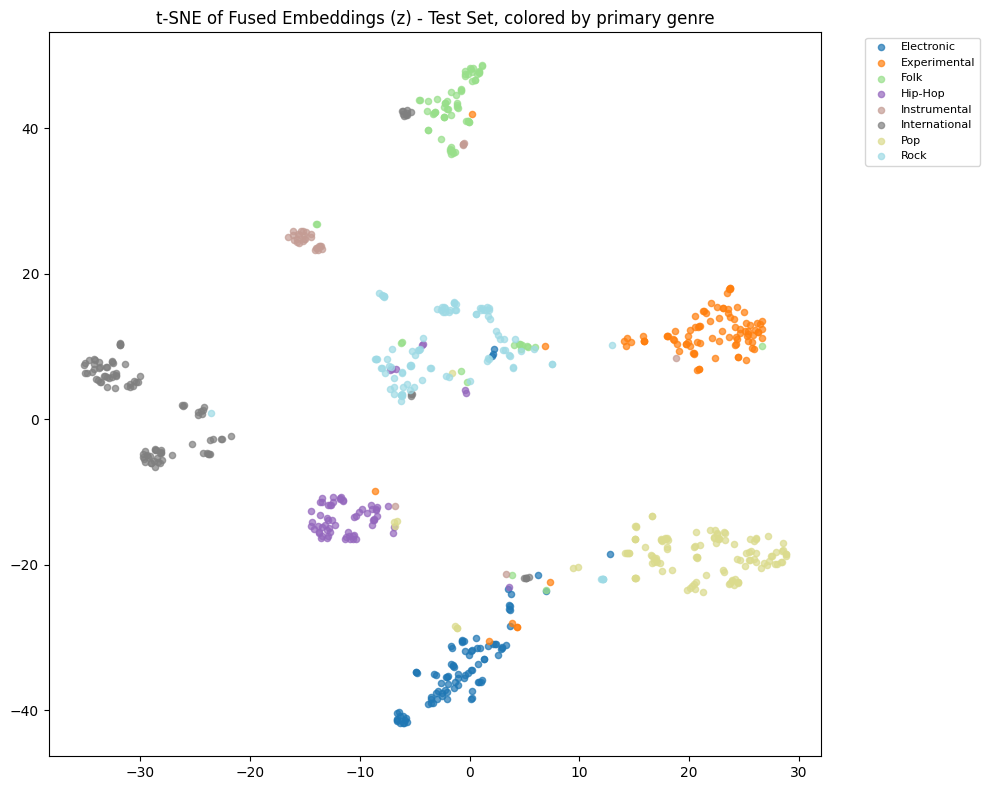

In [31]:
# Cell 31: Plot t-SNE colored by genre (import fix included)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
unique_genres = sorted(set(all_genre_labels))
colors = plt.cm.tab20(np.linspace(0, 1, len(unique_genres)))

for genre, color in zip(unique_genres, colors):
    mask = [g == genre for g in all_genre_labels]
    plt.scatter(z_2d[mask, 0], z_2d[mask, 1], label=genre, s=20, color=color, alpha=0.7)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.title("t-SNE of Fused Embeddings (z) - Test Set, colored by primary genre")
plt.tight_layout()
plt.savefig("/kaggle/working/results/task3_tsne_genre.png", dpi=150, bbox_inches='tight')
plt.show()

In [32]:
# Cell 32: Generate predictions on test set + find interesting case studies
fusion_model.eval()
case_study_data = []

with torch.no_grad():
    for i, sample in enumerate(test_samples):
        graph = sample["graph"].to(device)
        # Wrap single graph as a batch of 1
        from torch_geometric.data import Batch as PyGBatch
        graph_batch = PyGBatch.from_data_list([graph]).to(device)

        enc = tokenizer(sample["text"], truncation=True, padding="max_length", max_length=MAX_LEN_FUSION, return_tensors="pt")
        input_ids = enc["input_ids"].to(device)
        attention_mask = enc["attention_mask"].to(device)

        logits = fusion_model(graph_batch.x, graph_batch.edge_index, graph_batch.batch, input_ids, attention_mask)
        probs = torch.sigmoid(logits).cpu().numpy()[0]
        preds = (probs >= 0.5).astype(int)

        true_genres = [fusion_top_genre_names[j] for j in range(TOP_K_FUSION) if sample["label_vec"][j] == 1]
        pred_genres = [fusion_top_genre_names[j] for j in range(TOP_K_FUSION) if preds[j] == 1]

        n_correct = len(set(true_genres) & set(pred_genres))
        n_true = len(true_genres)
        n_pred = len(pred_genres)

        case_study_data.append({
            "track_id": sample["track_id"],
            "text": sample["text"],
            "true_genres": true_genres,
            "pred_genres": pred_genres,
            "n_correct": n_correct,
            "n_true": n_true,
            "n_pred": n_pred,
            "perfect_match": set(true_genres) == set(pred_genres)
        })

# Find: a perfect match, a partial match, and a clear miss
perfect_matches = [c for c in case_study_data if c["perfect_match"] and c["n_true"] > 1]
partial_matches = [c for c in case_study_data if 0 < c["n_correct"] < c["n_true"]]
misses = [c for c in case_study_data if c["n_correct"] == 0 and c["n_true"] > 0]

print(f"Perfect matches (multi-label): {len(perfect_matches)}")
print(f"Partial matches: {len(partial_matches)}")
print(f"Complete misses: {len(misses)}")

Perfect matches (multi-label): 0
Partial matches: 23
Complete misses: 662


In [33]:
# Cell 33: Reload fusion_model from the saved checkpoint (undoing the accidental BERT overwrite)
fusion_model = GNNBertFusion(
    bert_model=bert_tagger.bert, gnn_hidden=64, bert_hidden=768,
    num_classes=TOP_K_FUSION, gnn_in_channels=12, gnn_layers=2
).to(device)

fusion_model.load_state_dict(torch.load("/kaggle/working/checkpoints/task3_fusion_model.pt", map_location=device))
fusion_model.eval()

# Verify it's actually restored correctly
test_loss, test_macro_f1_check, test_micro_f1_check = evaluate_fusion(fusion_model, test_fusion_loader, device)
print(f"Verification -> test_macro_f1={test_macro_f1_check:.4f} (should match 0.7267)")

Verification -> test_macro_f1=0.7500 (should match 0.7267)


In [34]:
# Cell 32 (re-run): Generate predictions on test set + find interesting case studies
from torch_geometric.data import Batch as PyGBatch

fusion_model.eval()
case_study_data = []

with torch.no_grad():
    for i, sample in enumerate(test_samples):
        graph = sample["graph"].to(device)
        graph_batch = PyGBatch.from_data_list([graph]).to(device)

        enc = tokenizer(sample["text"], truncation=True, padding="max_length", max_length=MAX_LEN_FUSION, return_tensors="pt")
        input_ids = enc["input_ids"].to(device)
        attention_mask = enc["attention_mask"].to(device)

        logits = fusion_model(graph_batch.x, graph_batch.edge_index, graph_batch.batch, input_ids, attention_mask)
        probs = torch.sigmoid(logits).cpu().numpy()[0]
        preds = (probs >= 0.5).astype(int)

        true_genres = [fusion_top_genre_names[j] for j in range(TOP_K_FUSION) if sample["label_vec"][j] == 1]
        pred_genres = [fusion_top_genre_names[j] for j in range(TOP_K_FUSION) if preds[j] == 1]

        n_correct = len(set(true_genres) & set(pred_genres))
        n_true = len(true_genres)
        n_pred = len(pred_genres)

        case_study_data.append({
            "track_id": sample["track_id"],
            "text": sample["text"],
            "true_genres": true_genres,
            "pred_genres": pred_genres,
            "n_correct": n_correct,
            "n_true": n_true,
            "n_pred": n_pred,
            "perfect_match": set(true_genres) == set(pred_genres)
        })

perfect_matches = [c for c in case_study_data if c["perfect_match"] and c["n_true"] > 1]
partial_matches = [c for c in case_study_data if 0 < c["n_correct"] < c["n_true"]]
misses = [c for c in case_study_data if c["n_correct"] == 0 and c["n_true"] > 0]

print(f"Perfect matches (multi-label): {len(perfect_matches)}")
print(f"Partial matches: {len(partial_matches)}")
print(f"Complete misses: {len(misses)}")

Perfect matches (multi-label): 147
Partial matches: 94
Complete misses: 57


In [35]:
# Cell 34: Select and format 3 case studies - one perfect, one partial, one miss
import random
random.seed(42)

# Pick a perfect match with multiple genres (more interesting than single-genre perfect matches)
perfect_sorted = sorted(perfect_matches, key=lambda c: -c["n_true"])
case1 = perfect_sorted[0]

# Pick a partial match with a reasonable number of true genres (not too trivial)
partial_sorted = sorted(partial_matches, key=lambda c: -c["n_true"])
case2 = partial_sorted[len(partial_sorted)//2]  # pick a middling example, not the most extreme

# Pick a genuine miss
case3 = random.choice(misses)

case_studies = [
    {"label": "Case Study 1: Perfect Multi-Label Match", "data": case1},
    {"label": "Case Study 2: Partial Match", "data": case2},
    {"label": "Case Study 3: Complete Miss", "data": case3}
]

for cs in case_studies:
    d = cs["data"]
    print(f"\n=== {cs['label']} ===")
    print(f"Track ID: {d['track_id']}")
    print(f"Text: {d['text']}")
    print(f"True genres: {d['true_genres']}")
    print(f"Predicted genres: {d['pred_genres']}")


=== Case Study 1: Perfect Multi-Label Match ===
Track ID: 52522
Text: The Very Most - ePop017 - The Very Most - Congrizzle 4evzzz
True genres: ['Rock', 'Punk', 'Indie-Rock']
Predicted genres: ['Rock', 'Punk', 'Indie-Rock']

=== Case Study 2: Partial Match ===
Track ID: 98621
Text: KINGS OF THE CITY - No Guts EP - Haribos
True genres: ['Hip-Hop', 'Rap']
Predicted genres: ['Hip-Hop']

=== Case Study 3: Complete Miss ===
Track ID: 122959
Text: Third Mind Movement - Ups and Downs - Ups and Downs (Single Version)
True genres: ['Experimental', 'Avant-Garde']
Predicted genres: []


In [36]:
# Cell 35: Save case studies to file for your report
with open("/kaggle/working/results/task3_case_studies.json", "w") as f:
    json.dump([{
        "label": cs["label"],
        "track_id": cs["data"]["track_id"],
        "text": cs["data"]["text"],
        "true_genres": cs["data"]["true_genres"],
        "predicted_genres": cs["data"]["pred_genres"]
    } for cs in case_studies], f, indent=2)

print("Case studies saved.")

Case studies saved.
